# bench_ssl — Semi-Supervised Learning Benchmark

Benchmarks SSL algorithms across two modalities:
- **Vision**: CIFAR-10 with MeanTeacher, PseudoLabel, PiModel vs supervised baseline.
- **Tabular**: Forest Covertype with MeanTeacher and PseudoLabel vs supervised baseline.

`SSLVisionWrapper` and `SSLTabularWrapper` live in `ml_pipeline/pipelines_torch/ssl_wrappers.py`.
Each wrapper treats only a small subset of samples as labelled during `fit` (2 000 for vision,
500 for tabular) and uses the rest as unlabelled data; final accuracy is measured on a held-out
test split that no algorithm ever sees.


## Setup


In [1]:
import os, subprocess, sys
from pathlib import Path

cwd = Path.cwd()
repo_root = cwd.parent if cwd.name == "ml_pipeline" else cwd
if (repo_root / "ml_pipeline").is_dir() and (repo_root / "requirements.txt").is_file():
    os.chdir(repo_root)
    print(f"Using local checkout: {repo_root}")
else:
    subprocess.run(["rm", "-rf", "bench_research_ml_project"], check=True)
    subprocess.run(["git", "clone", "https://github.com/oremaz/bench_research_ml_project"], check=True)
    os.chdir("bench_research_ml_project")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

if Path.cwd().name != "ml_pipeline":
    os.chdir("ml_pipeline")
print(f"Working directory: {Path.cwd()}")


Using local checkout: /scratch/omazor/bench_research_ml_project
Working directory: /scratch/omazor/bench_research_ml_project/ml_pipeline


In [2]:
import numpy as np
import pandas as pd
import torch
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

from pipelines_torch.ssl_wrappers import SSLVisionWrapper, SSLTabularWrapper
from pipelines_torch.benchmark import BenchmarkRunner
from utils.utils import load_model_by_name

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def evaluate_ssl_checkpoints(model_cfgs, path_start, X_test, y_test):
    """Load each saved checkpoint and score it on the held-out test split."""
    rows = []
    for cfg in model_cfgs:
        try:
            model = load_model_by_name(cfg["class"], cfg["name"], cfg["params"], path_start=path_start)
        except FileNotFoundError:
            print(f"Skipping {cfg['name']}: checkpoint not found")
            continue
        model = model.to(device)
        preds = model.predict(X_test)
        rows.append({
            "model": cfg["name"],
            "accuracy": accuracy_score(y_test, preds),
            "f1_macro": f1_score(y_test, preds, average="macro"),
        })
    return pd.DataFrame(rows)


Using device: cuda


## 1. Vision — CIFAR-10
We compare four models on CIFAR-10:
- **Supervised baseline** — standard cross-entropy on 2 000 labelled samples only.
- **MeanTeacher** — consistency regularisation via an EMA teacher.
- **PseudoLabel** — high-confidence unlabelled predictions added to the supervised loss.
- **PiModel** — two stochastic forward passes encouraged to agree.


### 1.1 Dataset Preparation


In [3]:
print("Loading CIFAR-10 ...")
full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
X_vis = np.transpose(full_train.data, (0, 3, 1, 2)).astype(np.float32) / 255.0
X_vis = (X_vis - 0.5) / 0.5  # Normalise to [-1, 1]
y_vis = np.array(full_train.targets)

# Subsample to 15 000 for faster iteration
X_vis, _, y_vis, _ = train_test_split(
    X_vis, y_vis, train_size=15_000, stratify=y_vis, random_state=SEED
)

# Held-out test split, untouched by any SSL algorithm
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis, y_vis, test_size=2_000, stratify=y_vis, random_state=SEED
)
print(f"CIFAR-10 train: {X_vis_train.shape} | test: {X_vis_test.shape}")


Loading CIFAR-10 ...


  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 65.5k/170M [00:00<07:54, 359kB/s]

  0%|          | 164k/170M [00:00<04:30, 630kB/s] 

  0%|          | 328k/170M [00:00<02:49, 1.00MB/s]

...

 96%|█████████▌| 164M/170M [00:14<00:00, 22.3MB/s]

 97%|█████████▋| 166M/170M [00:14<00:00, 21.8MB/s]

 99%|█████████▊| 168M/170M [00:14<00:00, 22.1MB/s]

100%|██████████| 170M/170M [00:14<00:00, 11.5MB/s]

CIFAR-10 train: (13000, 3, 32, 32) | test: (2000, 3, 32, 32)


### 1.2 Benchmark


In [4]:
vision_models = [
    {"name": "Vision_Supervised",  "class": SSLVisionWrapper, "params": {"ssl_algo": "supervised"}},
    {"name": "Vision_MeanTeacher", "class": SSLVisionWrapper, "params": {"ssl_algo": "mean_teacher"}},
    {"name": "Vision_PseudoLabel", "class": SSLVisionWrapper, "params": {"ssl_algo": "pseudo_label"}},
    {"name": "Vision_PiModel",     "class": SSLVisionWrapper, "params": {"ssl_algo": "pi_model"}},
]

runner_vis = BenchmarkRunner(
    model_configs=vision_models,
    augmentations=[None],
    task_type="classification",
    device=str(device),
    epochs=5,
    batch_size=32,
    use_kfold=False,
    learning_rate=1e-3,
    use_wandb=True,
    path_start="ssl_vision",
    random_state=SEED,
)

print("\n--- Vision SSL Benchmark ---")
runner_vis.run(X_vis_train, y_vis_train)



--- Vision SSL Benchmark ---


Models:   0%|          | 0/4 [00:00<?, ?it/s]

Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/omazor/.netrc.


wandb: Currently logged in as: orel-mazor (orel-mazor-mines-paris-alumni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

wandb: 🚀 View run ssl_vision-Vision_PiModel-none at: https://wandb.ai/orel-mazor-mines-paris-alumni/bench-research-ml/runs/5cz7eo8n
wandb: ⭐️ View project at: https://wandb.ai/orel-mazor-mines-paris-alumni/bench-research-ml
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260720_030455-5cz7eo8n/logs


Augmentations: 100%|██████████| 1/1 [00:06<00:00,  6.32s/it]

Models: 100%|██████████| 4/4 [00:36<00:00,  7.74s/it]

Models: 100%|██████████| 4/4 [00:36<00:00,  9.19s/it]

### 1.3 Analysis


Loading model from: results/ssl_vision/bf4de4562d68.pt
✓ PyTorch model loaded from results/ssl_vision/bf4de4562d68.pt
Loading model from: results/ssl_vision/50ddf842ce00.pt
✓ PyTorch model loaded from results/ssl_vision/50ddf842ce00.pt


Loading model from: results/ssl_vision/9509cc3a63dc.pt
✓ PyTorch model loaded from results/ssl_vision/9509cc3a63dc.pt
Loading model from: results/ssl_vision/1e0fbb4df601.pt
✓ PyTorch model loaded from results/ssl_vision/1e0fbb4df601.pt
                model  accuracy  f1_macro
0   Vision_Supervised    0.4475  0.445399
1  Vision_MeanTeacher    0.4045  0.382970
2  Vision_PseudoLabel    0.4340  0.407621
3      Vision_PiModel    0.4305  0.402539


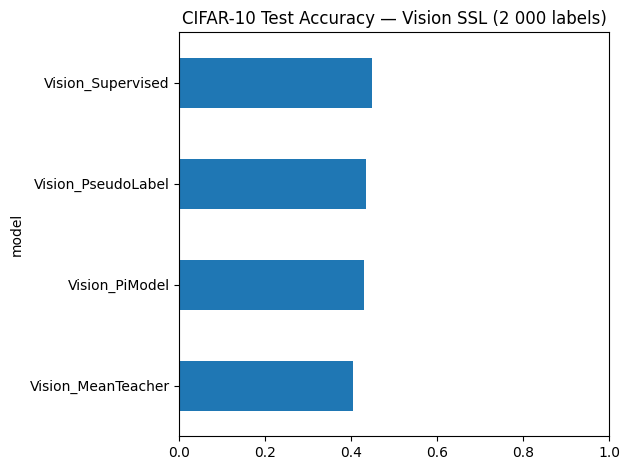

In [5]:
vis_df = evaluate_ssl_checkpoints(vision_models, "ssl_vision", X_vis_test, y_vis_test)
print(vis_df)

if not vis_df.empty:
    vis_df.set_index("model")["accuracy"].sort_values().plot(
        kind="barh", title="CIFAR-10 Test Accuracy — Vision SSL (2 000 labels)", xlim=(0, 1)
    )
    plt.tight_layout(); plt.show()


## 2. Tabular — Forest Covertype
Only **500 samples** are treated as labelled; the remaining training samples are unlabelled
(~3% label ratio). This is where SSL algorithms are expected to shine most.


### 2.1 Dataset Preparation


In [6]:
from sklearn.datasets import fetch_covtype

print("Fetching Forest Covertype dataset ...")
covtype = fetch_covtype()
X_tab_raw = covtype.data
y_tab_raw = covtype.target - 1  # labels 1-7 -> 0-6

# Subsample to 20 000 for speed
X_tab_raw, _, y_tab_raw, _ = train_test_split(
    X_tab_raw, y_tab_raw, train_size=20_000, stratify=y_tab_raw, random_state=SEED
)

X_tab_train, X_tab_test, y_tab_train, y_tab_test = train_test_split(
    X_tab_raw, y_tab_raw, test_size=4_000, stratify=y_tab_raw, random_state=SEED
)

# Fit the scaler on the training split only
scaler = StandardScaler().fit(X_tab_train)
X_tab_train = scaler.transform(X_tab_train).astype(np.float32)
X_tab_test = scaler.transform(X_tab_test).astype(np.float32)
print(f"Covertype train: {X_tab_train.shape} | test: {X_tab_test.shape} | classes: {len(set(y_tab_train))}")


Fetching Forest Covertype dataset ...


Covertype train: (16000, 54) | test: (4000, 54) | classes: 7


### 2.2 Benchmark


In [7]:
tabular_models = [
    {"name": "Tabular_Supervised",  "class": SSLTabularWrapper,
     "params": {"ssl_algo": "supervised", "input_dim": X_tab_train.shape[1], "num_classes": 7}},
    {"name": "Tabular_MeanTeacher", "class": SSLTabularWrapper,
     "params": {"ssl_algo": "mean_teacher", "input_dim": X_tab_train.shape[1], "num_classes": 7}},
    {"name": "Tabular_PseudoLabel", "class": SSLTabularWrapper,
     "params": {"ssl_algo": "pseudo_label", "input_dim": X_tab_train.shape[1], "num_classes": 7}},
]

runner_tab = BenchmarkRunner(
    model_configs=tabular_models,
    augmentations=[None],
    task_type="classification",
    device=str(device),
    epochs=10,
    batch_size=32,
    use_kfold=False,
    learning_rate=1e-3,
    use_wandb=True,
    path_start="ssl_tabular",
    random_state=SEED,
)

print("\n--- Tabular SSL Benchmark ---")
runner_tab.run(X_tab_train, y_tab_train)



--- Tabular SSL Benchmark ---


Models:   0%|          | 0/3 [00:00<?, ?it/s]

Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Tracking run with wandb version 0.28.1


wandb: Run data is saved locally in /scratch/omazor/bench_research_ml_project/ml_pipeline/wandb/run-20260720_030653-8gb16e8j
wandb: Run `wandb offline` to turn off syncing.


...

wandb: 🚀 View run ssl_tabular-Tabular_PseudoLabel-none at: https://wandb.ai/orel-mazor-mines-paris-alumni/bench-research-ml/runs/t3sau96e
wandb: ⭐️ View project at: https://wandb.ai/orel-mazor-mines-paris-alumni/bench-research-ml
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260720_030702-t3sau96e/logs


Augmentations: 100%|██████████| 1/1 [00:04<00:00,  4.24s/it]

Models: 100%|██████████| 3/3 [00:13<00:00,  4.39s/it]

Models: 100%|██████████| 3/3 [00:13<00:00,  4.43s/it]

### 2.3 Analysis


Loading model from: results/ssl_tabular/42387d1574f0.pt
✓ PyTorch model loaded from results/ssl_tabular/42387d1574f0.pt
Loading model from: results/ssl_tabular/3df923ee673d.pt
✓ PyTorch model loaded from results/ssl_tabular/3df923ee673d.pt
Loading model from: results/ssl_tabular/b8dae5f5b00c.pt
✓ PyTorch model loaded from results/ssl_tabular/b8dae5f5b00c.pt
                 model  accuracy  f1_macro
0   Tabular_Supervised    0.6515  0.346722
1  Tabular_MeanTeacher    0.6685  0.378204
2  Tabular_PseudoLabel    0.6545  0.372984


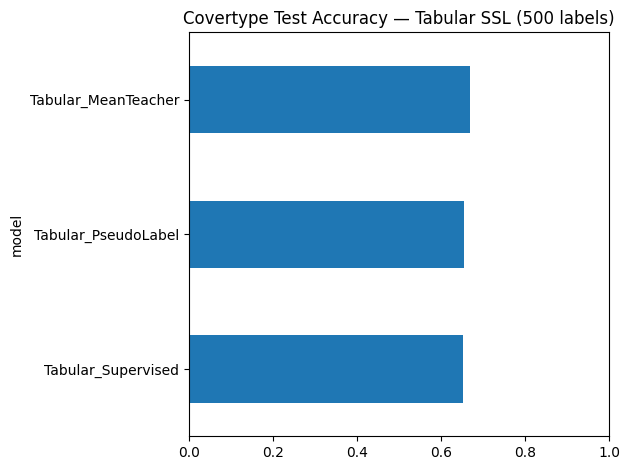

In [8]:
tab_df = evaluate_ssl_checkpoints(tabular_models, "ssl_tabular", X_tab_test, y_tab_test)
print(tab_df)

if not tab_df.empty:
    tab_df.set_index("model")["accuracy"].sort_values().plot(
        kind="barh", title="Covertype Test Accuracy — Tabular SSL (500 labels)", xlim=(0, 1)
    )
    plt.tight_layout(); plt.show()


## 3. Summary

The bar charts above report held-out test accuracy for every algorithm.

**Takeaways**:
- SSL benefit is most visible when the labelled set is extremely small (500 labels for Covertype).
- MeanTeacher typically outperforms PseudoLabel at low label ratios due to smoother consistency targets.
- The wrappers in `ssl_wrappers.py` can be reused directly: swap `input_dim`, `num_classes`, or `ssl_algo`.
